## 1-Setup

In [1]:
# Local project setup
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()

print("Project root:", PROJECT_ROOT)
print("Contents:", os.listdir(PROJECT_ROOT))

Project root: /Volumes/T7/Deep Learning Project/deep-learning-video-inpainting-project-1
Contents: ['.git', 'data', 'ECE685_Video_inpainting.ipynb', 'models', 'README.md', 'outputs', 'ECE_VideoInpainting_HuggingFace.ipynb', 'figures', 'scripts', '.gitignore', '._ECE_VideoInpainting_HuggingFace.ipynb']


In [ ]:
# Uncomment when running for the first time to install dependencies
# %pip install -q diffusers==0.24.0 huggingface_hub==0.25.0 transformers==4.38.0 accelerate==0.27.0 peft==0.9.0

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Clone AnimateDiff only if it is not already present
import os

if not os.path.exists("animatediff"):
    !git clone https://github.com/guoyww/AnimateDiff.git animatediff
else:
    print("animatediff folder already exists")

Cloning into 'animatediff'...
remote: Enumerating objects: 718, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 718 (delta 213), reused 194 (delta 194), pack-reused 431 (from 1)
Receiving objects: 100% (718/718), 60.36 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (297/297), done.


In [ ]:
import sys

sys.path.append("animatediff")

print("Added animatediff to path")

Added animatediff to path


In [ ]:
import os

print(os.listdir("animatediff"))

['.git', '._.git', '.gitignore', '._.gitignore', 'LICENSE.txt', '._LICENSE.txt', 'README.md', '._README.md', '__assets__', '.___assets__', 'animatediff', '._animatediff', 'app.py', '._app.py', 'configs', '._configs', 'models', '._models', 'requirements.txt', '._requirements.txt', 'scripts', '._scripts', 'train.py', '._train.py']


In [ ]:
# import os

# os.makedirs("data/raw", exist_ok=True)
# os.makedirs("data/processed", exist_ok=True)
# os.makedirs("models/base_sd", exist_ok=True)
# os.makedirs("models/motion_module", exist_ok=True)
# os.makedirs("outputs", exist_ok=True)

# print("Folders ready")

Folders ready


In [ ]:
from huggingface_hub import login
import os
from getpass import getpass

HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN is None:
    HF_TOKEN = getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /Users/arushisingh/.cache/huggingface/token
Login successful


In [7]:
from huggingface_hub import snapshot_download
import os

os.makedirs("models/base_sd", exist_ok=True)

snapshot_download(
    repo_id="runwayml/stable-diffusion-v1-5",
    local_dir="models/base_sd",
    local_dir_use_symlinks=False,
)

print("Base SD model downloaded to models/base_sd")

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1204: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 36 files:   0%|          | 0/36 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.bin:   0%|          | 0.00/167M [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Base SD model downloaded to models/base_sd


In [ ]:
from huggingface_hub import hf_hub_download
import os

os.makedirs("models/motion_module", exist_ok=True)

motion_path = hf_hub_download(
    repo_id="guoyww/animatediff",
    filename="mm_sd_v15_v2.ckpt",
    local_dir="models/motion_module",
    local_dir_use_symlinks=False,
)

print("Motion module downloaded to:", motion_path)

mm_sd_v15_v2.ckpt:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

Motion module downloaded to: models/motion_module/mm_sd_v15_v2.ckpt


In [9]:
import os

print("base_sd files:", os.listdir("models/base_sd")[:10])
print("motion_module files:", os.listdir("models/motion_module"))

base_sd files: ['.cache', '._.cache', 'safety_checker', '._safety_checker', 'feature_extractor', '._feature_extractor', '.gitattributes', '._.gitattributes', 'scheduler', '._scheduler']
motion_module files: ['.cache', '._.cache', 'mm_sd_v15_v2.ckpt', '._mm_sd_v15_v2.ckpt']


## 2- Load the pipeline

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float32  # safest for Mac/MPS

print("device:", device)
print("dtype:", dtype)

pipe = StableDiffusionPipeline.from_pretrained(
    "models/base_sd",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)

pipe = pipe.to(device)
print("Base SD pipeline loaded")

W0417 19:16:27.477000 34545 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


device: mps
dtype: torch.float32


/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Base SD pipeline loaded


  0%|          | 0/10 [00:00<?, ?it/s]

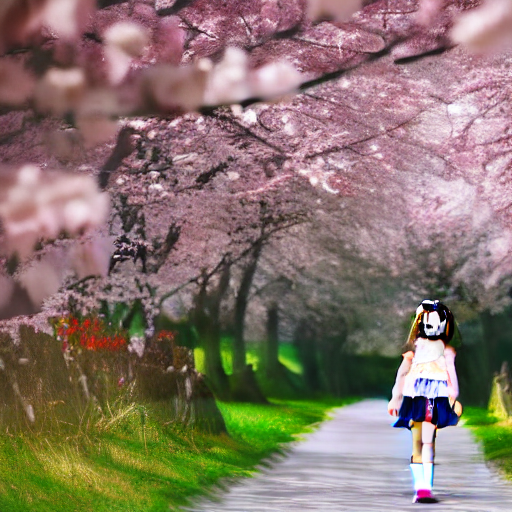

In [ ]:
# Test the pipeline with a simple prompt

prompt = "an anime girl walking under cherry blossoms, cinematic, high quality"
image = pipe(prompt, num_inference_steps=10).images[0]
image

In [ ]:
# Load AnimateDiff pipeline

import torch
from diffusers import AnimateDiffPipeline, MotionAdapter, DDIMScheduler

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float32  # safest on Mac

print("device:", device)
print("dtype:", dtype)

adapter = MotionAdapter.from_pretrained(
    "guoyww/animatediff-motion-adapter-v1-5-2", torch_dtype=dtype
)

anim_pipe = AnimateDiffPipeline.from_pretrained(
    "models/base_sd",
    motion_adapter=adapter,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)

anim_pipe.scheduler = DDIMScheduler.from_pretrained(
    "models/base_sd",
    subfolder="scheduler",
    clip_sample=False,
    timestep_spacing="linspace",
    beta_schedule="linear",
    steps_offset=1,
)

anim_pipe = anim_pipe.to(device)
anim_pipe.enable_attention_slicing()

print("AnimateDiff pipeline loaded")

device: mps
dtype: torch.float32


/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.
Keyword arguments {'safety_checker': None, 'requires_safety_checker': False} are not expected by AnimateDiffPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

The config attributes {'center_input_sample': False, 'flip_sin_to_cos': True, 'freq_shift': 0, 'attention_head_dim': 8} were passed to UNetMotionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


AnimateDiff pipeline loaded


In [ ]:
# Test with a very small clip

from diffusers.utils import export_to_gif
import os

os.makedirs("outputs", exist_ok=True)

prompt = (
    "anime girl walking under cherry blossoms, cinematic, high quality, soft lighting"
)

output = anim_pipe(
    prompt=prompt,
    negative_prompt="blurry, low quality, distorted, worst quality",
    num_frames=4,  # ↓ from 8 → 4
    num_inference_steps=4,  # ↓ from 8 → 4
    height=256,  # ↓ from 512 → 256
    width=256,  # ↓ from 512 → 256
    guidance_scale=6.0,  # slightly lower = lighter compute
    generator=torch.Generator(device=device).manual_seed(42),
)

gif_path = "outputs/test_anim_small.gif"
export_to_gif(output.frames[0], gif_path)

print("Saved to:", gif_path)

  0%|          | 0/4 [00:00<?, ?it/s]

Saved to: outputs/test_anim_small.gif


In [15]:
import gc
import torch

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("Cleared memory")

Cleared memory


In [ ]:
# from diffusers.utils import export_to_gif
# import os

# os.makedirs("outputs", exist_ok=True)

# prompt = "anime girl walking under cherry blossoms, cinematic, high quality, soft lighting, detailed anime background"

# output = anim_pipe(
#     prompt=prompt,
#     negative_prompt="blurry, noisy, distorted, low quality, worst quality, deformed",
#     num_frames=4,
#     num_inference_steps=8,
#     height=256,
#     width=256,
#     guidance_scale=7.5,
#     generator=torch.Generator(device=device).manual_seed(42),
# )

# gif_path = "outputs/test_anim_better.gif"
# export_to_gif(output.frames[0], gif_path)

# print("Saved to:", gif_path)

  0%|          | 0/8 [00:00<?, ?it/s]

Saved to: outputs/test_anim_better.gif


In [ ]:
import gc
import torch

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

from diffusers.utils import export_to_gif
import os

prompt = "anime girl walking under cherry blossom trees, soft lighting, cinematic, anime style, detailed"

output = anim_pipe(
    prompt=prompt,
    negative_prompt="blurry, noisy, distorted, worst quality, glitch, artifacts",
    num_frames=4,
    num_inference_steps=15,  # BIG change (8 → 15)
    height=256,
    width=256,
    guidance_scale=6.5,  # slightly lower = more stable
    generator=torch.Generator(device=device).manual_seed(42),
)

gif_path = "outputs/test_anim_stable.gif"
export_to_gif(output.frames[0], gif_path)

print("Saved to:", gif_path)

  0%|          | 0/15 [00:00<?, ?it/s]

Saved to: outputs/test_anim_stable.gif


## 3- Test with JacobLin Data

In [ ]:
# Test if files exist

from pathlib import Path

raw_dir = Path("data/raw")

print("Exists:", raw_dir.exists())
print("Files:")
for p in sorted(raw_dir.rglob("*")):
    if p.is_file():
        print(p)

Exists: True
Files:
data/raw/.gitkeep


In [19]:
import os

os.makedirs("data/raw/sample_clip", exist_ok=True)
print("Ready for sample clip")

Ready for sample clip


In [ ]:
from huggingface_hub import whoami

print(whoami())

{'type': 'user', 'id': '69d919c82dec445814b2c66e', 'name': 'arushi40868', 'fullname': 'Arushi Singh', 'email': 'arushi40868@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1777593600, 'isPro': False, 'avatarUrl': '/avatars/79e5d76b06225b86b871e865cc5e9655.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'ECE_FinalProj', 'role': 'write', 'createdAt': '2026-04-17T22:00:59.690Z'}}}


In [ ]:
from huggingface_hub import list_repo_files

files = list_repo_files(repo_id="JacobLinCool/anime-2024", repo_type="dataset")

print("Number of files:", len(files))
for f in files[:100]:
    print(f)

Number of files: 2129
.gitattributes
README.md
config/all/metadata.jsonl
config/fall/metadata.jsonl
config/spring/metadata.jsonl
config/summer/metadata.jsonl
config/winter/metadata.jsonl
videos/2024-01/36837.mp4
videos/2024-01/36838.mp4
videos/2024-01/36839.mp4
videos/2024-01/36840.mp4
videos/2024-01/36841.mp4
videos/2024-01/36842.mp4
videos/2024-01/36846.mp4
videos/2024-01/36849.mp4
videos/2024-01/36850.mp4
videos/2024-01/36851.mp4
videos/2024-01/36852.mp4
videos/2024-01/36853.mp4
videos/2024-01/36854.mp4
videos/2024-01/36855.mp4
videos/2024-01/36856.mp4
videos/2024-01/36857.mp4
videos/2024-01/36858.mp4
videos/2024-01/36859.mp4
videos/2024-01/36860.mp4
videos/2024-01/36863.mp4
videos/2024-01/36864.mp4
videos/2024-01/36865.mp4
videos/2024-01/36868.mp4
videos/2024-01/36869.mp4
videos/2024-01/36870.mp4
videos/2024-01/36876.mp4
videos/2024-01/36877.mp4
videos/2024-01/36878.mp4
videos/2024-01/36879.mp4
videos/2024-01/36880.mp4
videos/2024-01/36881.mp4
videos/2024-01/36882.mp4
videos/2024-0

In [ ]:
# Download 1 clip

from huggingface_hub import snapshot_download
import os

os.makedirs("data/raw/jacoblin_sample", exist_ok=True)

local_path = snapshot_download(
    repo_id="JacobLinCool/anime-2024",
    repo_type="dataset",
    local_dir="data/raw/jacoblin_sample",
    local_dir_use_symlinks=False,
    allow_patterns=["videos/2024-01/36837.mp4"],
)

print("Downloaded to:", local_path)

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1204: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

36837.mp4:   0%|          | 0.00/65.6M [00:00<?, ?B/s]

Downloaded to: /Volumes/T7/Deep Learning Project/deep-learning-video-inpainting-project-1/data/raw/jacoblin_sample


In [25]:
from pathlib import Path

for p in Path("data/raw/jacoblin_sample").rglob("*"):
    if p.is_file():
        print(p)

data/raw/jacoblin_sample/._.cache
data/raw/jacoblin_sample/._videos
data/raw/jacoblin_sample/.cache/._huggingface
data/raw/jacoblin_sample/.cache/huggingface/._download
data/raw/jacoblin_sample/.cache/huggingface/.gitignore
data/raw/jacoblin_sample/.cache/huggingface/._.gitignore
data/raw/jacoblin_sample/.cache/huggingface/download/._videos
data/raw/jacoblin_sample/.cache/huggingface/download/videos/._2024-01
data/raw/jacoblin_sample/.cache/huggingface/download/videos/2024-01/36837.mp4.metadata
data/raw/jacoblin_sample/.cache/huggingface/download/videos/2024-01/._36837.mp4.metadata
data/raw/jacoblin_sample/videos/._2024-01
data/raw/jacoblin_sample/videos/2024-01/36837.mp4
data/raw/jacoblin_sample/videos/2024-01/._36837.mp4


In [26]:
import cv2
from pathlib import Path

video_path = Path("data/raw/jacoblin_sample/videos/2024-01/36837.mp4")
assert video_path.exists(), f"Missing file: {video_path}"

cap = cv2.VideoCapture(str(video_path))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Video path:", video_path)
print("Frame count:", frame_count)
print("FPS:", fps)
print("Resolution:", width, "x", height)

cap.release()

Video path: data/raw/jacoblin_sample/videos/2024-01/36837.mp4
Frame count: 34046
FPS: 23.97602406982676
Resolution: 640 x 360


In [27]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(str(video_path))

frames = []
max_frames = 8

while len(frames) < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames.append(frame)

cap.release()

print("Extracted frames:", len(frames))
print("Single frame shape:", frames[0].shape if frames else None)

Extracted frames: 8
Single frame shape: (360, 640, 3)


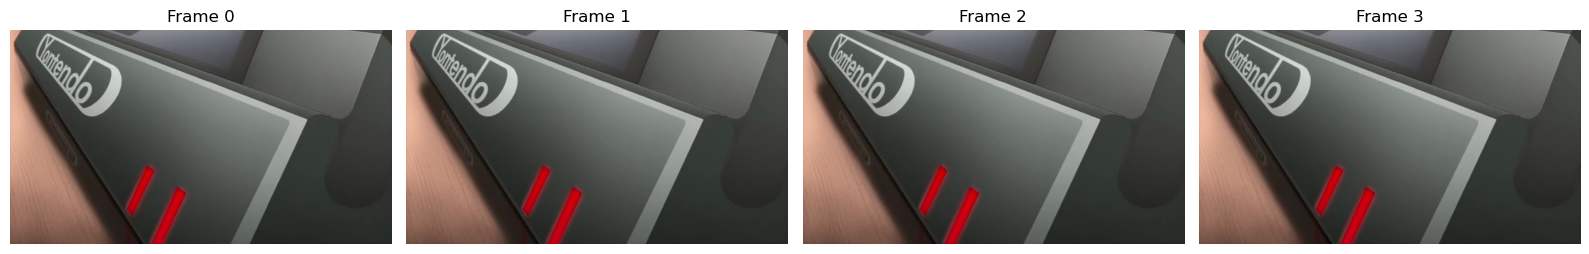

In [28]:
fig, axes = plt.subplots(1, min(4, len(frames)), figsize=(16, 4))

if len(frames) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.imshow(frames[i])
    ax.set_title(f"Frame {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

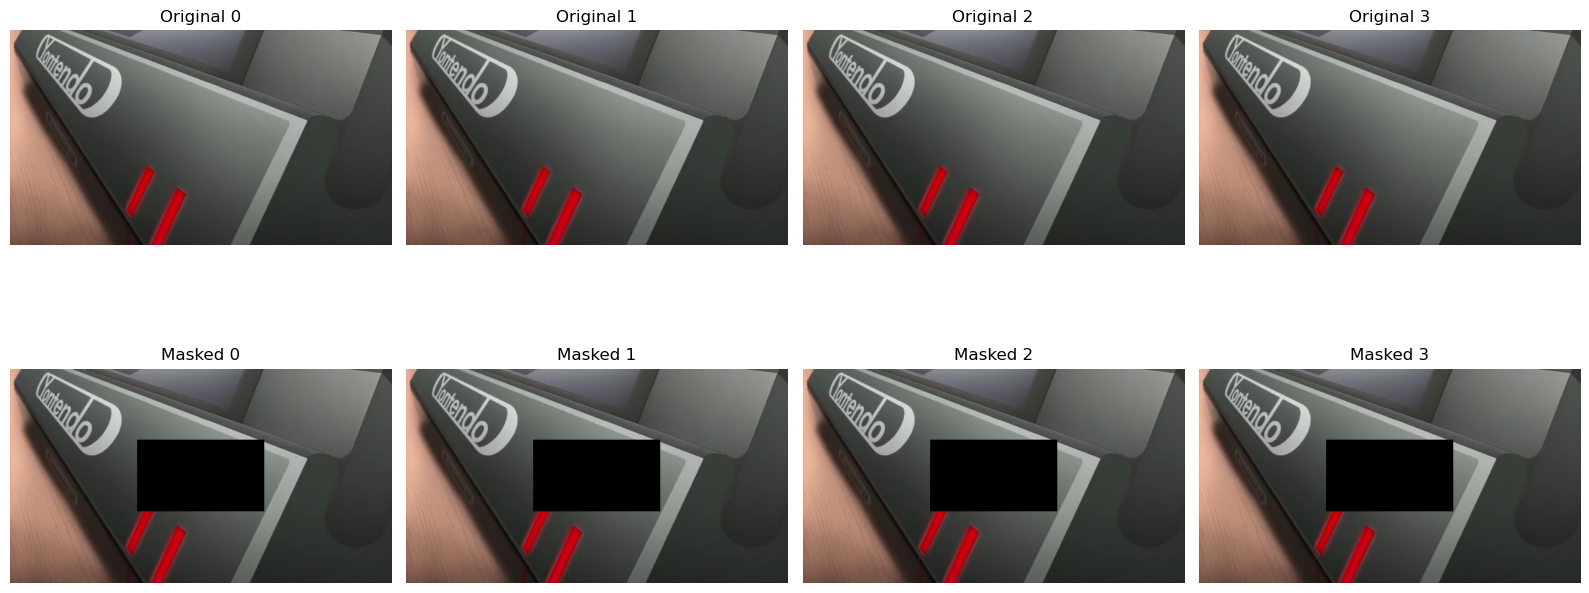

In [29]:
import numpy as np
import matplotlib.pyplot as plt

H, W, _ = frames[0].shape

mask = np.zeros((H, W), dtype=np.uint8)

# center rectangle mask
mh, mw = H // 3, W // 3
y1 = (H - mh) // 2
y2 = y1 + mh
x1 = (W - mw) // 2
x2 = x1 + mw

mask[y1:y2, x1:x2] = 255

masked_frames = []
for frame in frames:
    masked = frame.copy()
    masked[mask == 255] = 0
    masked_frames.append(masked)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    axes[0, i].imshow(frames[i])
    axes[0, i].set_title(f"Original {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(masked_frames[i])
    axes[1, i].set_title(f"Masked {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [30]:
import torch
import numpy as np

# Convert frames → tensor
frames_np = np.stack(frames)  # (T, H, W, C)
frames_np = frames_np.astype(np.float32) / 255.0

frames_tensor = torch.from_numpy(frames_np).permute(0, 3, 1, 2)  # (T, C, H, W)

# Convert mask → tensor
mask_np = (mask > 0).astype(np.float32)  # binary mask
mask_np = np.stack([mask_np] * len(frames))  # (T, H, W)

mask_tensor = torch.from_numpy(mask_np).unsqueeze(1)  # (T, 1, H, W)

print("frames:", frames_tensor.shape)
print("mask:", mask_tensor.shape)

frames: torch.Size([8, 3, 360, 640])
mask: torch.Size([8, 1, 360, 640])


In [ ]:
# Resize frames and masks for MAC

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

target_h, target_w = 256, 256

# Resize frames: (T, 3, H, W) -> (T, 3, 256, 256)
frames_small = F.interpolate(
    frames_tensor, size=(target_h, target_w), mode="bilinear", align_corners=False
)

# Resize masks: (T, 1, H, W) -> (T, 1, 256, 256)
mask_small = F.interpolate(mask_tensor, size=(target_h, target_w), mode="nearest")

# Make binary again just in case
mask_small = (mask_small > 0.5).float()

# Create masked input
masked_frames_small = frames_small * (1 - mask_small)

print("frames_small:", frames_small.shape)
print("mask_small:", mask_small.shape)
print("masked_frames_small:", masked_frames_small.shape)

frames_small: torch.Size([8, 3, 256, 256])
mask_small: torch.Size([8, 1, 256, 256])
masked_frames_small: torch.Size([8, 3, 256, 256])


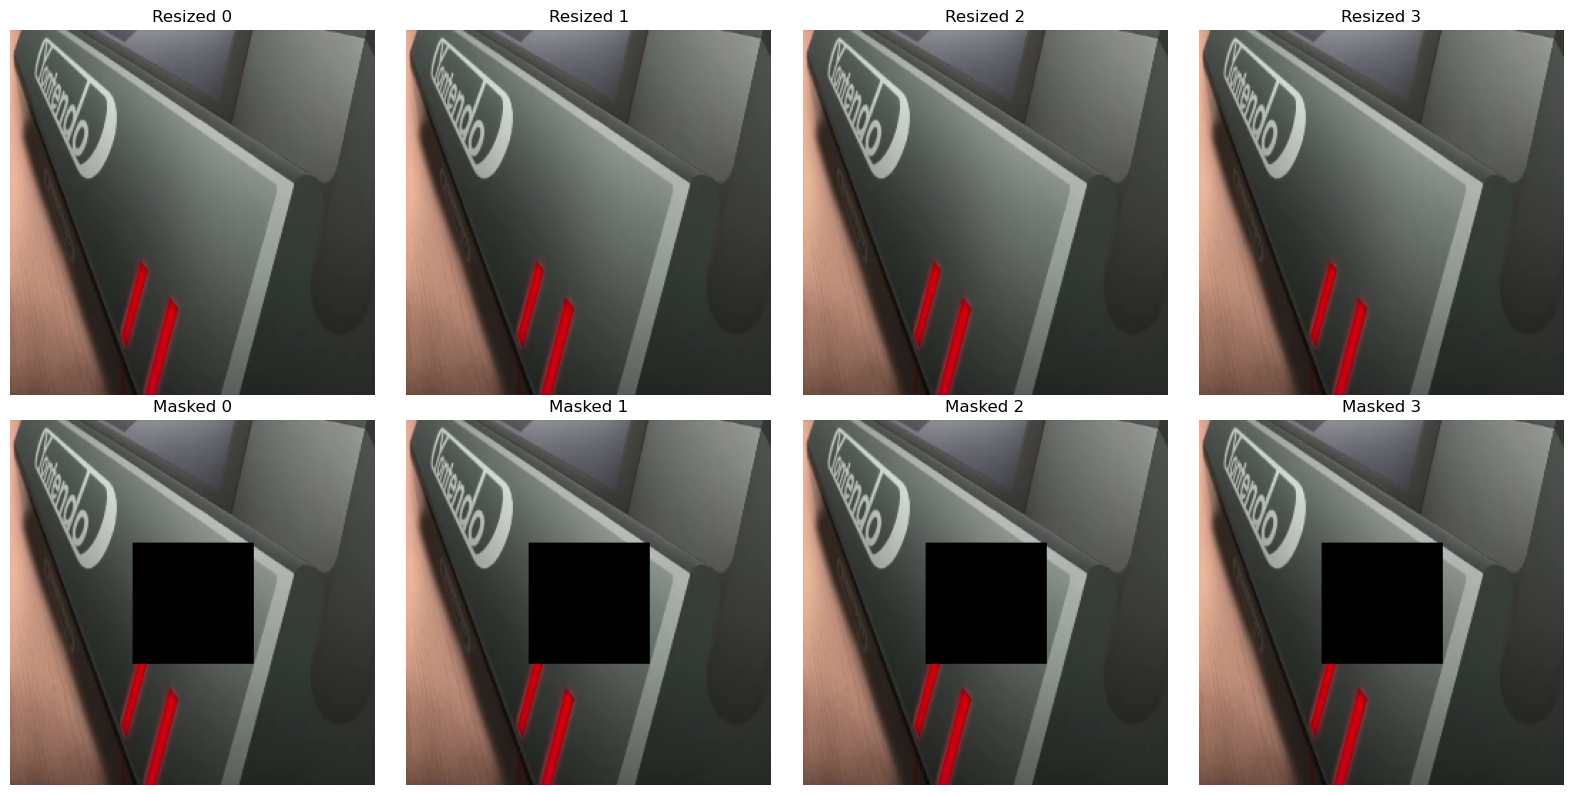

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    orig = frames_small[i].permute(1, 2, 0).cpu().numpy()
    masked = masked_frames_small[i].permute(1, 2, 0).cpu().numpy()

    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"Resized {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(masked)
    axes[1, i].set_title(f"Masked {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [34]:
# Load an inpainting pipeline for testing

import torch
from diffusers import StableDiffusionInpaintPipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float32  # safest on Mac

inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-inpainting",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)

inpaint_pipe = inpaint_pipe.to(device)
inpaint_pipe.enable_attention_slicing()

print("Inpainting pipeline loaded")

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors not found


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Inpainting pipeline loaded


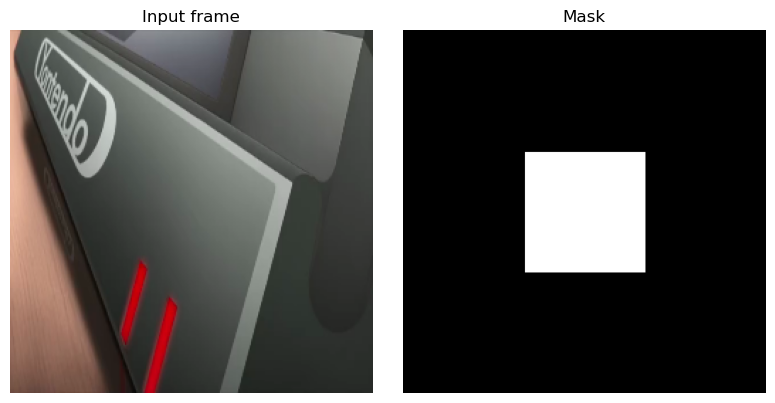

In [35]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# pick one frame
idx = 0

frame_np = (frames_small[idx].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
mask_np = (mask_small[idx, 0].cpu().numpy() * 255).astype(np.uint8)

init_image = Image.fromarray(frame_np)
mask_image = Image.fromarray(mask_np).convert("L")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Input frame")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.tight_layout()
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

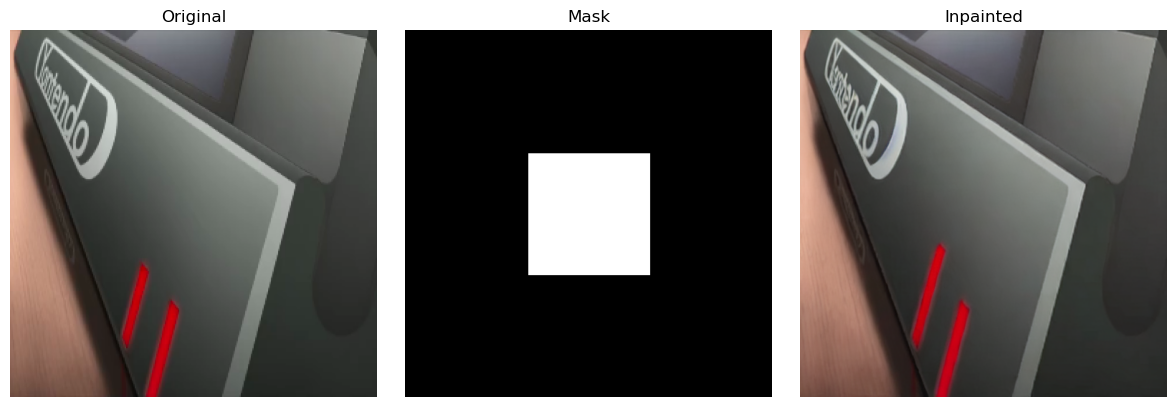

In [ ]:
prompt = "anime handheld gaming device surface, clean shading, consistent anime style, smooth details"
negative_prompt = "blurry, noisy, distorted, warped, extra objects, text, worst quality"

result = inpaint_pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=20,
    guidance_scale=7.5,
    strength=1.0,
).images[0]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(init_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("Inpainted")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Run on all frames (this is just a test, not the final code)

results = []

for i in range(len(frames_small)):
    frame_np = (frames_small[i].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    mask_np = (mask_small[i, 0].cpu().numpy() * 255).astype(np.uint8)

    init_image = Image.fromarray(frame_np)
    mask_image = Image.fromarray(mask_np).convert("L")

    result = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=init_image,
        mask_image=mask_image,
        num_inference_steps=20,
        guidance_scale=7.5,
        strength=1.0,
    ).images[0]

    results.append(result)

print("Finished all frames")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Finished all frames


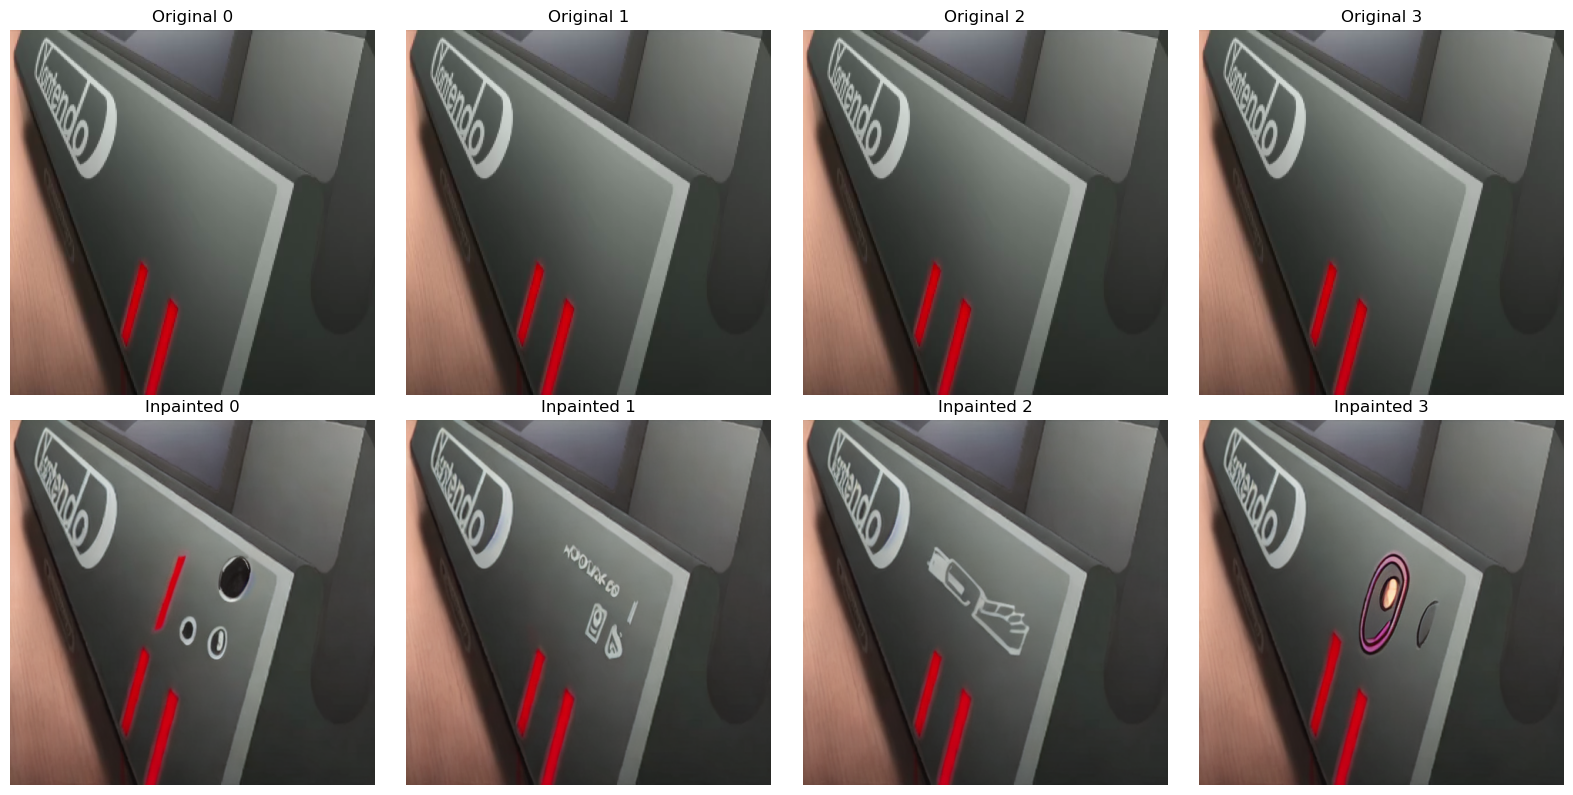

In [ ]:
# Visualize results

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    axes[0, i].imshow(frames_small[i].permute(1, 2, 0))
    axes[0, i].set_title(f"Original {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(results[i])
    axes[1, i].set_title(f"Inpainted {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()